# Bike Sharing Demand Prediction

## Import the libraries

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

## Loading the dataset

In [2]:
bikes = pd.read_csv('hour.csv')
bikes

,index,date,season,year,month,hour,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,demand
0,1,01-01-2011,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,01-01-2011,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,01-01-2011,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,01-01-2011,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,01-01-2011,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,31-12-2012,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,31-12-2012,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,31-12-2012,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,31-12-2012,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


## Prelim analysis and feature selection

### Drop unnecessary feature

In [3]:
bikes_prep = bikes.copy()
bikes_prep = bikes_prep.drop(['index', 'date', 'casual', 'registered'], axis=1)
bikes_prep.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed,demand
0,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


### Check for missing values

In [4]:
bikes_prep.isna().sum()

season        0
year          0
month         0
hour          0
holiday       0
weekday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
demand        0
dtype: int64

### Visualize the dataset (to check the distribution)

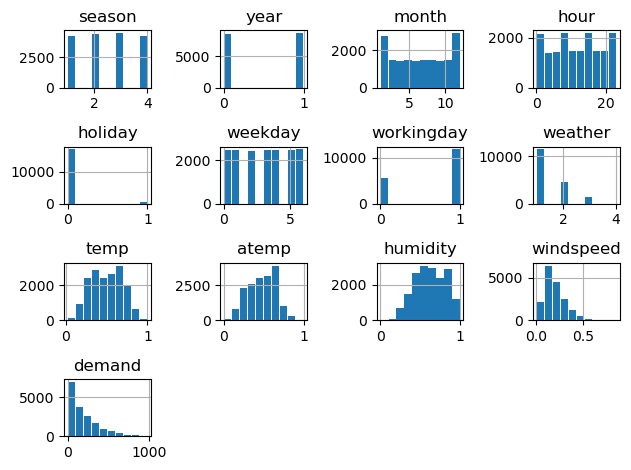

In [5]:
bikes_prep.hist(rwidth=0.9)
plt.tight_layout()

## Visualization of independent vs dependent
### Plot the continuous variables

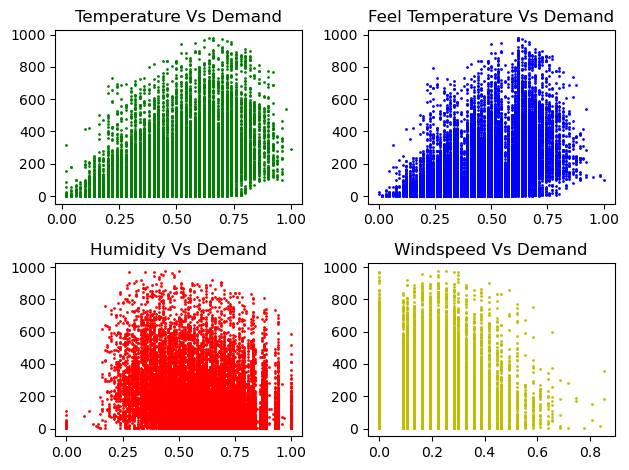

In [6]:
plt.subplot(2, 2, 1)
plt.scatter(bikes_prep['temp'], bikes_prep['demand'], s=1, c='g')
plt.title('Temperature Vs Demand')

plt.subplot(2, 2, 2)
plt.scatter(bikes_prep['atemp'], bikes_prep['demand'], s=1, c='b')
plt.title('Feel Temperature Vs Demand')

plt.subplot(2, 2, 3)
plt.scatter(bikes_prep['humidity'], bikes_prep['demand'], s=1, c='r')
plt.title('Humidity Vs Demand')

plt.subplot(2, 2, 4)
plt.scatter(bikes_prep['windspeed'], bikes_prep['demand'], s=1, c='y')
plt.title('Windspeed Vs Demand')

plt.tight_layout()

### Plot the categorical variables

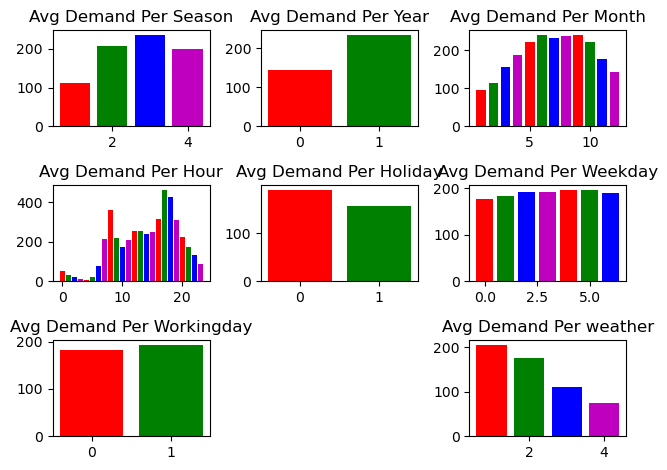

In [7]:
avg_demand_per_season = bikes_prep.groupby('season').mean()['demand']
plt.subplot(3, 3, 1)
plt.bar(avg_demand_per_season.index, avg_demand_per_season.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Season')

avg_demand_per_year = bikes_prep.groupby('year').mean()['demand']
plt.subplot(3, 3, 2)
plt.bar(avg_demand_per_year.index, avg_demand_per_year.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Year')

avg_demand_per_month = bikes_prep.groupby('month').mean()['demand']
plt.subplot(3, 3, 3)
plt.bar(avg_demand_per_month.index, avg_demand_per_month.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Month')

avg_demand_per_hour = bikes_prep.groupby('hour').mean()['demand']
plt.subplot(3, 3, 4)
plt.bar(avg_demand_per_hour.index, avg_demand_per_hour.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Hour')

avg_demand_per_holiday = bikes_prep.groupby('holiday').mean()['demand']
plt.subplot(3, 3, 5)
plt.bar(avg_demand_per_holiday.index, avg_demand_per_holiday.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Holiday')

avg_demand_per_weekday = bikes_prep.groupby('weekday').mean()['demand']
plt.subplot(3, 3, 6)
plt.bar(avg_demand_per_weekday.index, avg_demand_per_weekday.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Weekday')

avg_demand_per_workingday = bikes_prep.groupby('workingday').mean()['demand']
plt.subplot(3, 3, 7)
plt.bar(avg_demand_per_workingday.index, avg_demand_per_workingday.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Workingday')

avg_demand_per_weather = bikes_prep.groupby('weather').mean()['demand']
plt.subplot(3, 3, 9)
plt.bar(avg_demand_per_weather.index, avg_demand_per_weather.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per weather')

plt.tight_layout()

Text(0.5, 1.0, 'Avg Demand Per Hour')

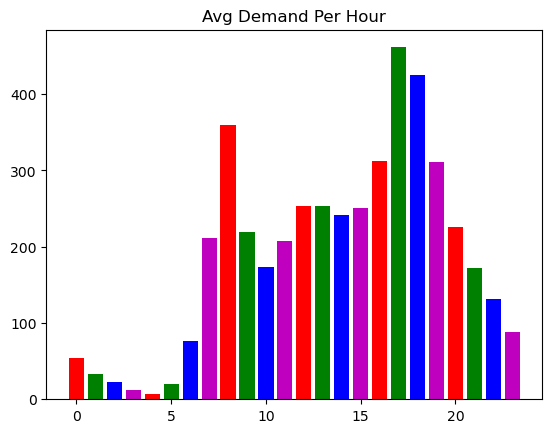

In [8]:
avg_demand_per_hour = bikes_prep.groupby('hour').mean()['demand']
plt.bar(avg_demand_per_hour.index, avg_demand_per_hour.values, color=['r', 'g', 'b', 'm'])
plt.title('Avg Demand Per Hour')

## Check outliers and Multi linear assumption
### Check for outliers

In [9]:
bikes_prep.describe()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed,demand
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,189.463088
std,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,181.387599
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,40.000000
50%,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,142.000000
75%,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,281.000000
max,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,977.000000


In [10]:
bikes_prep['demand'].describe()

count    17379.000000
mean       189.463088
std        181.387599
min          1.000000
25%         40.000000
50%        142.000000
75%        281.000000
max        977.000000
Name: demand, dtype: float64

### Check the correlation coefficients

In [11]:
correlation = bikes_prep[['temp', 'atemp', 'humidity', 'windspeed', 'demand']].corr()
correlation

,temp,atemp,humidity,windspeed,demand
temp,1.000000,0.987672,-0.069881,-0.023125,0.404772
atemp,0.987672,1.000000,-0.051918,-0.062336,0.400929
humidity,-0.069881,-0.051918,1.000000,-0.290105,-0.322911
windspeed,-0.023125,-0.062336,-0.290105,1.000000,0.093234
demand,0.404772,0.400929,-0.322911,0.093234,1.000000


### Drop strong correlation and no correlation features

In [12]:
bikes_prep.drop(['atemp', 'windspeed', 'weekday', 'workingday', 'year'], axis=1, inplace=True)
bikes_prep.head()

,season,month,hour,holiday,weather,temp,humidity,demand
0,1,1,0,0,1,0.24,0.81,16
1,1,1,1,0,1,0.22,0.80,40
2,1,1,2,0,1,0.22,0.80,32
3,1,1,3,0,1,0.24,0.75,13
4,1,1,4,0,1,0.24,0.75,1


### Check for autocorrelation

(array([-12, -11, -10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,
          1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12]),
 array([0.45474694, 0.47049532, 0.49622782, 0.49404034, 0.46795911,
        0.47732017, 0.52675743, 0.59145716, 0.65201544, 0.71519514,
        0.80590981, 0.92530928, 1.        , 0.92530928, 0.80590981,
        0.71519514, 0.65201544, 0.59145716, 0.52675743, 0.47732017,
        0.46795911, 0.49404034, 0.49622782, 0.47049532, 0.45474694]),
 <matplotlib.lines.Line2D at 0x1520f20f0>)

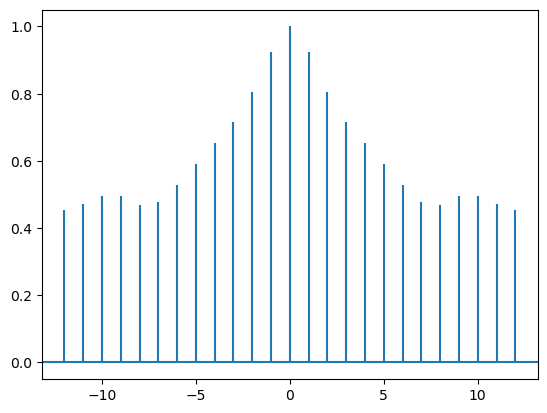

In [13]:
plt.acorr(bikes_prep['demand'], maxlags=12)

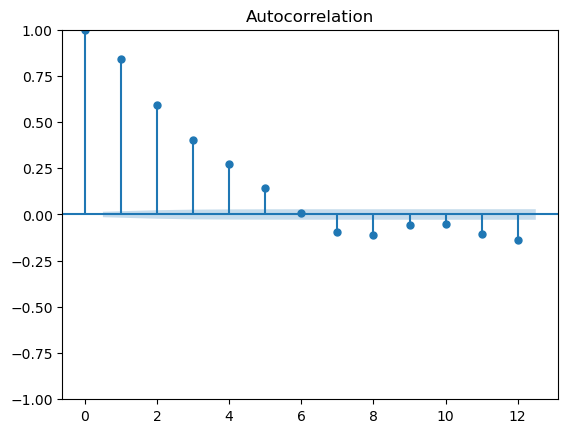

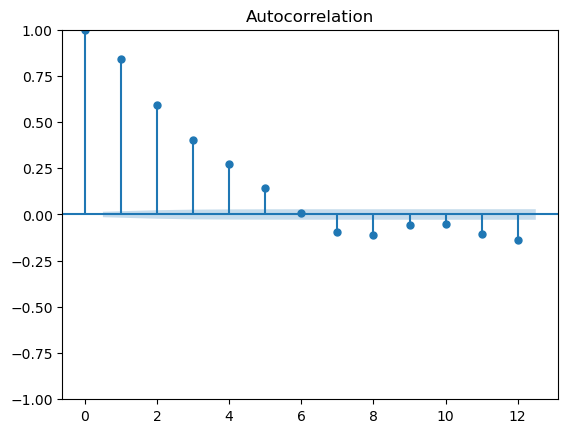

In [14]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(bikes_prep['demand'], lags=12)

In [15]:
t_1 = bikes_prep['demand'].shift(+1).to_frame()
t_1.columns = ['t-1']

t_2 = bikes_prep['demand'].shift(+2).to_frame()
t_2.columns = ['t-2']

t_3 = bikes_prep['demand'].shift(+3).to_frame()
t_3.columns = ['t-3']

bikes_prep_lag = pd.concat([bikes_prep, t_1, t_2, t_3], axis=1)
bikes_prep_lag

,season,month,hour,holiday,weather,temp,humidity,demand,t-1,t-2,t-3
0,1,1,0,0,1,0.24,0.81,16,NaN,NaN,NaN
1,1,1,1,0,1,0.22,0.80,40,16.0,NaN,NaN
2,1,1,2,0,1,0.22,0.80,32,40.0,16.0,NaN
3,1,1,3,0,1,0.24,0.75,13,32.0,40.0,16.0
4,1,1,4,0,1,0.24,0.75,1,13.0,32.0,40.0
...,...,...,...,...,...,...,...,...,...,...,...
17374,1,12,19,0,2,0.26,0.60,119,122.0,164.0,214.0
17375,1,12,20,0,2,0.26,0.60,89,119.0,122.0,164.0
17376,1,12,21,0,1,0.26,0.60,90,89.0,119.0,122.0
17377,1,12,22,0,1,0.26,0.56,61,90.0,89.0,119.0


### Drop NaN rows

In [16]:
bikes_prep_lag.dropna(inplace=True)
bikes_prep_lag

,season,month,hour,holiday,weather,temp,humidity,demand,t-1,t-2,t-3
3,1,1,3,0,1,0.24,0.75,13,32.0,40.0,16.0
4,1,1,4,0,1,0.24,0.75,1,13.0,32.0,40.0
5,1,1,5,0,2,0.24,0.75,1,1.0,13.0,32.0
6,1,1,6,0,1,0.22,0.80,2,1.0,1.0,13.0
7,1,1,7,0,1,0.20,0.86,3,2.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
17374,1,12,19,0,2,0.26,0.60,119,122.0,164.0,214.0
17375,1,12,20,0,2,0.26,0.60,89,119.0,122.0,164.0
17376,1,12,21,0,1,0.26,0.60,90,89.0,119.0,122.0
17377,1,12,22,0,1,0.26,0.56,61,90.0,89.0,119.0


### Need to check and fix the normality in demand feature

<Axes: >

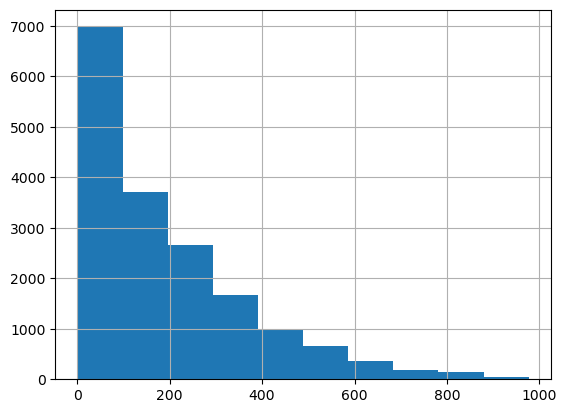

In [17]:
bikes_prep['demand'].hist()

<Axes: >

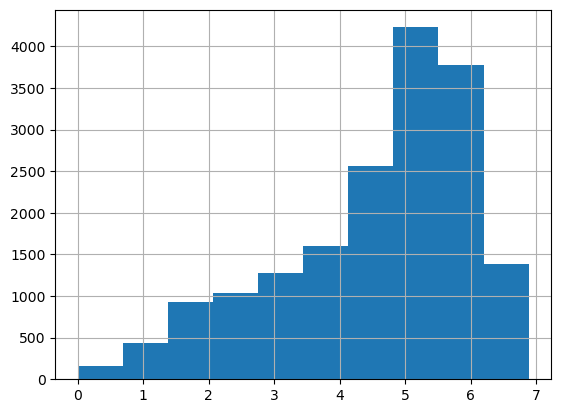

In [18]:
log_bike_demand = np.log(bikes_prep['demand'])
log_bike_demand.hist()

In [19]:
bikes_prep_lag['log_demand'] = np.log(bikes_prep['demand'])
bikes_prep_lag

,season,month,hour,holiday,weather,temp,humidity,demand,t-1,t-2,t-3,log_demand
3,1,1,3,0,1,0.24,0.75,13,32.0,40.0,16.0,2.564949
4,1,1,4,0,1,0.24,0.75,1,13.0,32.0,40.0,0.000000
5,1,1,5,0,2,0.24,0.75,1,1.0,13.0,32.0,0.000000
6,1,1,6,0,1,0.22,0.80,2,1.0,1.0,13.0,0.693147
7,1,1,7,0,1,0.20,0.86,3,2.0,1.0,1.0,1.098612
...,...,...,...,...,...,...,...,...,...,...,...,...
17374,1,12,19,0,2,0.26,0.60,119,122.0,164.0,214.0,4.779123
17375,1,12,20,0,2,0.26,0.60,89,119.0,122.0,164.0,4.488636
17376,1,12,21,0,1,0.26,0.60,90,89.0,119.0,122.0,4.499810
17377,1,12,22,0,1,0.26,0.56,61,90.0,89.0,119.0,4.110874


## Create dummy variables and drop_first (season, holiday, weather, month, hour)

In [20]:
bikes_prep_lag.dtypes

season          int64
month           int64
hour            int64
holiday         int64
weather         int64
temp          float64
humidity      float64
demand          int64
t-1           float64
t-2           float64
t-3           float64
log_demand    float64
dtype: object

#### Convert to category types

In [21]:
bikes_prep_lag['season'] = bikes_prep_lag['season'].astype('category')
bikes_prep_lag['holiday'] = bikes_prep_lag['holiday'].astype('category')
bikes_prep_lag['weather'] = bikes_prep_lag['weather'].astype('category')
bikes_prep_lag['month'] = bikes_prep_lag['month'].astype('category')
bikes_prep_lag['hour'] = bikes_prep_lag['hour'].astype('category')
bikes_prep_lag.dtypes

season        category
month         category
hour          category
holiday       category
weather       category
temp           float64
humidity       float64
demand           int64
t-1            float64
t-2            float64
t-3            float64
log_demand     float64
dtype: object

In [22]:
bikes_prep_lag = pd.get_dummies(bikes_prep_lag, drop_first=True)
bikes_prep_lag          

,temp,humidity,demand,t-1,t-2,t-3,log_demand,season_2,season_3,season_4,...,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23,holiday_1,weather_2,weather_3,weather_4
3,0.24,0.75,13,32.0,40.0,16.0,2.564949,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.24,0.75,1,13.0,32.0,40.0,0.000000,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,0.24,0.75,1,1.0,13.0,32.0,0.000000,False,False,False,...,False,False,False,False,False,False,False,True,False,False
6,0.22,0.80,2,1.0,1.0,13.0,0.693147,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7,0.20,0.86,3,2.0,1.0,1.0,1.098612,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,0.26,0.60,119,122.0,164.0,214.0,4.779123,False,False,False,...,False,True,False,False,False,False,False,True,False,False
17375,0.26,0.60,89,119.0,122.0,164.0,4.488636,False,False,False,...,False,False,True,False,False,False,False,True,False,False
17376,0.26,0.60,90,89.0,119.0,122.0,4.499810,False,False,False,...,False,False,False,True,False,False,False,False,False,False
17377,0.26,0.56,61,90.0,89.0,119.0,4.110874,False,False,False,...,False,False,False,False,True,False,False,False,False,False
